In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# import warnings
# warnings.filterwarnings('ignore')

In [2]:
plt.style.use('ggplot')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Load dataset
df = pd.read_csv('ADANIPORTS.csv')
print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (3322, 15)


In [4]:
display(df.head())

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,27-11-2007,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687720e+15,NaN,9859619,0.3612
1,28-11-2007,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312770e+14,NaN,1453278,0.3172
2,29-11-2007,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550660e+14,NaN,1069678,0.2088
3,30-11-2007,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283260e+14,NaN,1260913,0.2735
4,03-12-2007,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


In [5]:
display(df.dtypes)

Date                   object
Symbol                 object
Series                 object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume      int64
%Deliverble           float64
dtype: object

In [6]:
display(df.describe(include='all'))

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,3322,3322,3322,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3.322000e+03,3.322000e+03,2.456000e+03,3.322000e+03,3322.000000
unique,3322,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,30-04-2021,ADANIPORTS,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2299,3322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,344.114314,344.763019,351.608007,337.531969,344.239539,344.201626,344.853182,2.954564e+06,1.070144e+14,4.492259e+04,1.207441e+06,0.445899
std,NaN,NaN,NaN,192.936882,193.619992,198.617808,188.676614,193.187813,193.045886,193.841305,4.104227e+06,2.625564e+14,5.023124e+04,1.398640e+06,0.160496
min,NaN,NaN,NaN,108.000000,108.000000,110.450000,105.650000,108.000000,108.000000,108.340000,1.236600e+04,2.415860e+11,3.660000e+02,5.383000e+03,0.067000
25%,NaN,NaN,NaN,164.312500,164.850000,168.000000,161.600000,164.075000,164.312500,164.855000,7.493682e+05,1.817652e+13,2.083200e+04,3.212005e+05,0.332900
50%,NaN,NaN,NaN,324.700000,325.750000,331.275000,319.850000,325.000000,324.700000,325.765000,2.007292e+06,5.836045e+13,3.588150e+04,8.132775e+05,0.445650
75%,NaN,NaN,NaN,400.912500,401.000000,407.187500,395.000000,400.912500,400.912500,400.607500,3.636883e+06,1.158525e+14,5.336875e+04,1.605528e+06,0.555850


In [7]:
print("\nMissing values:")
display(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:


Trades    866
dtype: int64

In [8]:
# Impute 'Trades' if exists
if 'Trades' in df.columns:
    df['Trades'].fillna(df['Trades'].median(), inplace=True)

C:\Users\91932\AppData\Local\Temp\ipykernel_16016\3689291881.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Trades'].fillna(df['Trades'].median(), inplace=True)


In [9]:
# Categorical, binary, and continuous identification
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
binary_cols = [col for col in df.columns if df[col].dropna().nunique() == 2]
continuous_cols = [col for col in df.columns if col not in categorical_cols + binary_cols]

categorical_cols

['Date', 'Symbol', 'Series']

In [10]:
binary_cols

['Symbol']

In [11]:
continuous_cols

['Prev Close',
 'Open',
 'High',
 'Low',
 'Last',
 'Close',
 'VWAP',
 'Volume',
 'Turnover',
 'Trades',
 'Deliverable Volume',
 '%Deliverble']

In [12]:
# Descriptive stats (mean, median, mode, std, min, max)
print("\nDescriptive Statistics:")
desc_stats = {
    'Mean': df[continuous_cols].mean(),
    'Median': df[continuous_cols].median(),
    'Mode': df[continuous_cols].mode().iloc[0],
    'Std': df[continuous_cols].std(),
    'Min': df[continuous_cols].min(),
    'Max': df[continuous_cols].max()
}
display(pd.DataFrame(desc_stats))


Descriptive Statistics:


,Mean,Median,Mode,Std,Min,Max
Prev Close,3.441143e+02,3.247000e+02,1.379500e+02,1.929369e+02,1.080000e+02,1.307450e+03
Open,3.447630e+02,3.257500e+02,1.430000e+02,1.936200e+02,1.080000e+02,1.310250e+03
High,3.516080e+02,3.312750e+02,1.525000e+02,1.986178e+02,1.104500e+02,1.324000e+03
Low,3.375320e+02,3.198500e+02,1.440000e+02,1.886766e+02,1.056500e+02,1.270000e+03
Last,3.442395e+02,3.250000e+02,1.460000e+02,1.931878e+02,1.080000e+02,1.308000e+03
Close,3.442016e+02,3.247000e+02,1.379500e+02,1.930459e+02,1.080000e+02,1.307450e+03
VWAP,3.448532e+02,3.257650e+02,1.230400e+02,1.938413e+02,1.083400e+02,1.302150e+03
Volume,2.954564e+06,2.007292e+06,1.236600e+04,4.104227e+06,1.236600e+04,9.771788e+07
Turnover,1.070144e+14,5.836045e+13,2.593170e+13,2.625564e+14,2.415860e+11,8.160990e+15
Trades,4.256570e+04,3.588150e+04,3.588150e+04,4.337026e+04,3.660000e+02,1.205984e+06



Normality Tests (Shapiro-Wilk):
Prev Close p-value: 0.0000 - Not normal


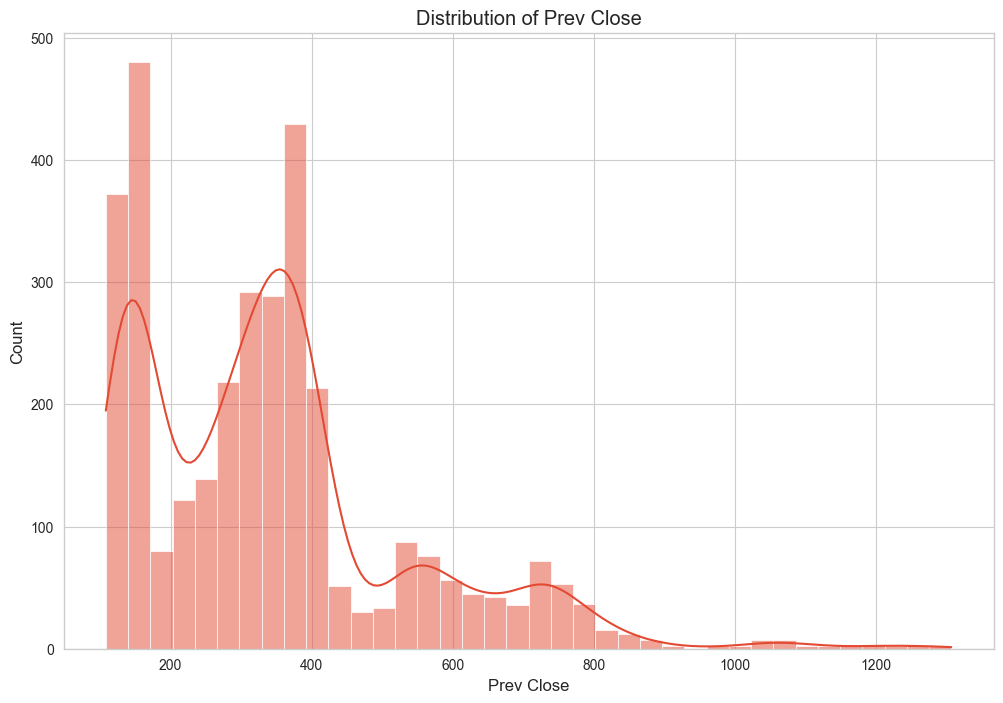

Open p-value: 0.0000 - Not normal


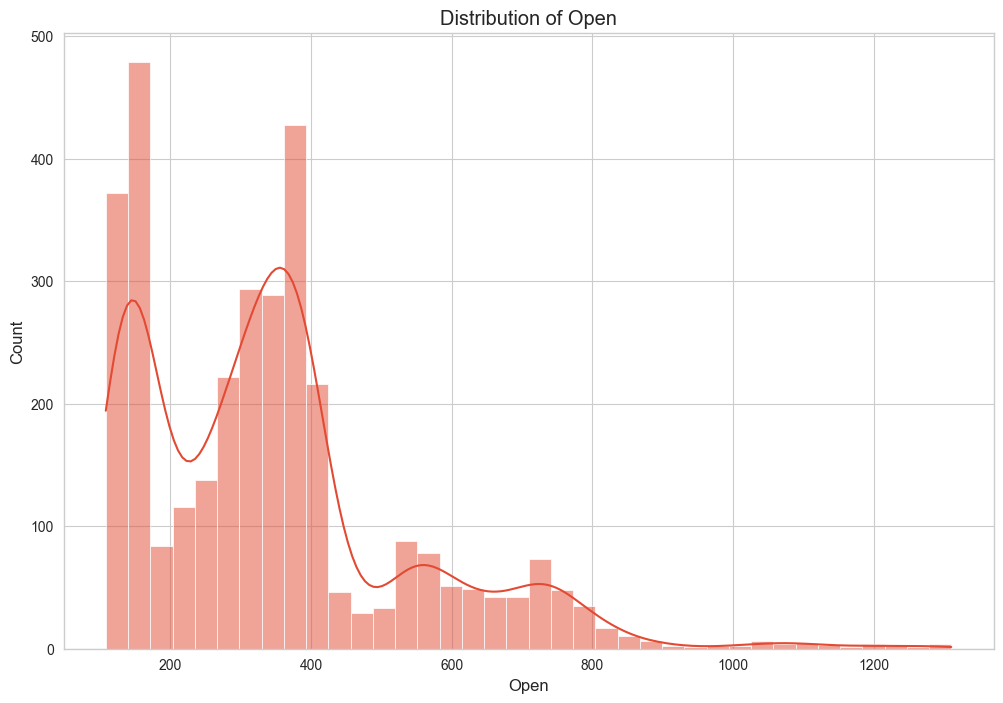

Close p-value: 0.0000 - Not normal


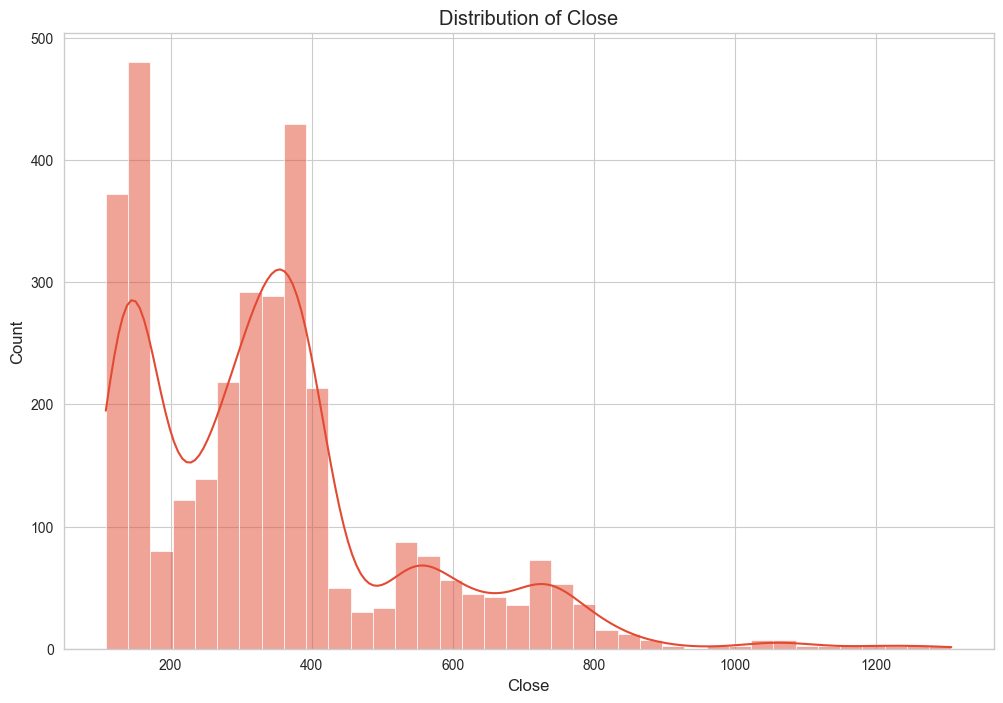

In [13]:
# Normality Check (Shapiro-Wilk Test)
print("\nNormality Tests (Shapiro-Wilk):")
for col in ['Prev Close', 'Open', 'Close']:
    if col in df.columns:
        sample = df[col].dropna().sample(n=min(5000, df[col].dropna().shape[0]))
        stat, p = stats.shapiro(sample)
        print(f"{col} p-value: {p:.4f} - {'Not normal' if p < 0.05 else 'Approximately normal'}")
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()


Correlation Matrix:


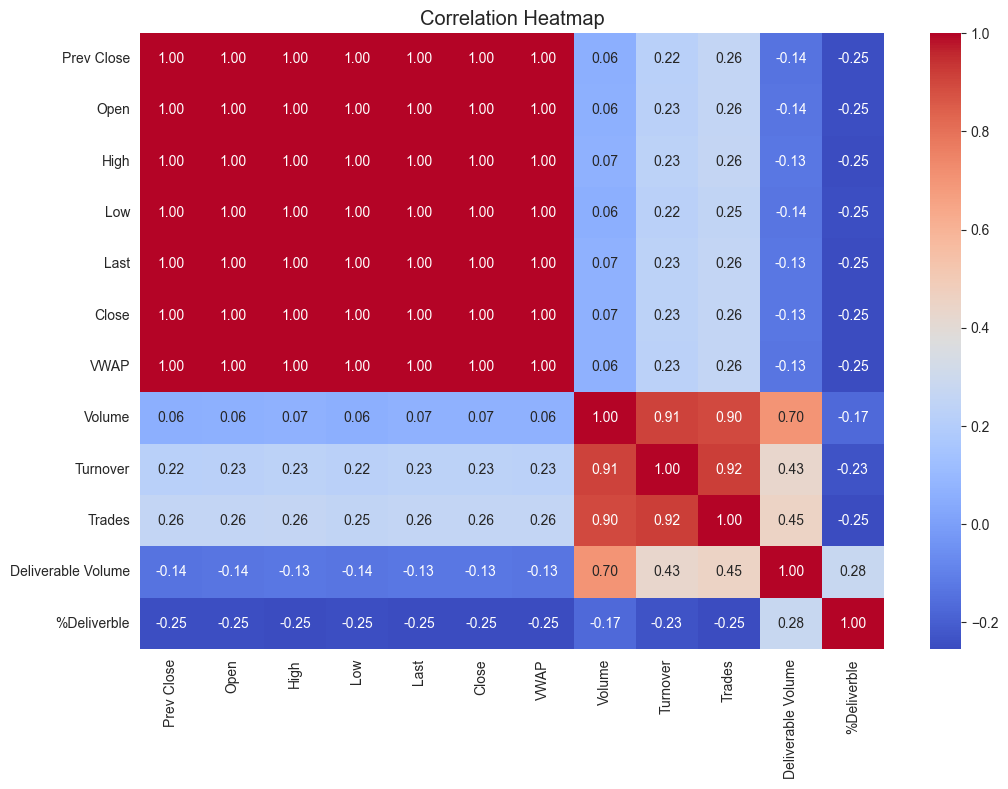

In [14]:
# Correlation Analysis
if len(continuous_cols) > 1:
    print("\nCorrelation Matrix:")
    corr = df[continuous_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap')
    plt.show()

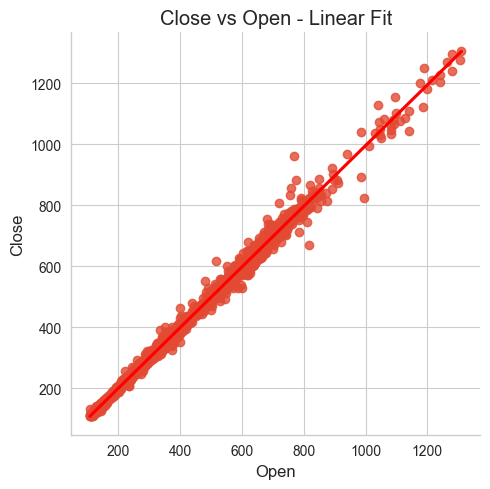

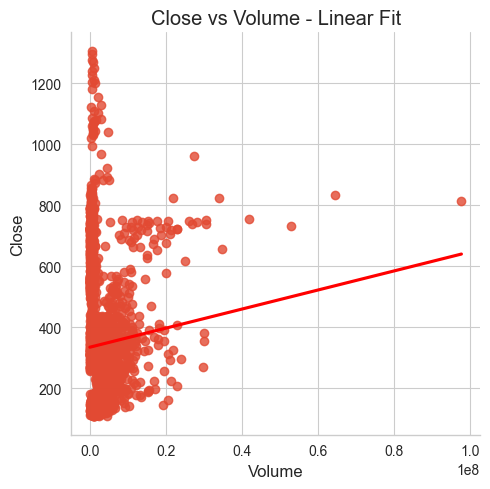

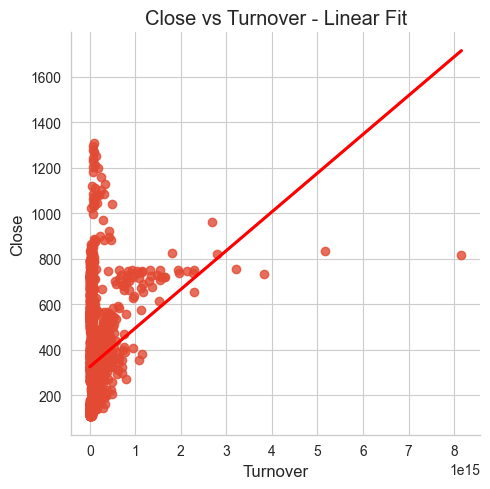

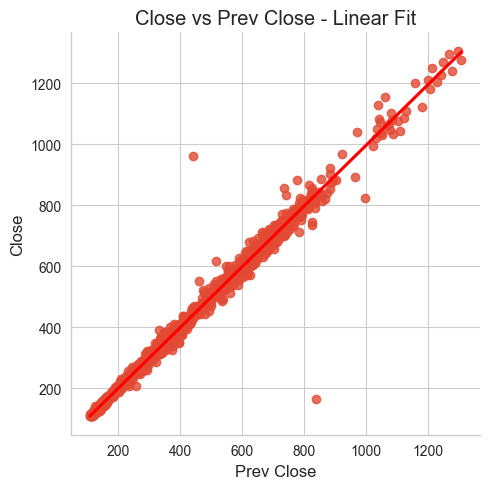

In [15]:
# Simple linearity check without LOWESS
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Close'
check_features = ['Open', 'Volume', 'Turnover', 'Prev Close', 'Daily Change']

check_features = [col for col in check_features if col in df.columns]

for feature in check_features:
    sns.lmplot(data=df, x=feature, y=target_col, ci=None, line_kws={"color": "red"})
    plt.title(f'{target_col} vs {feature} - Linear Fit')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [16]:
# Drop highly correlated redundant columns
drop_cols = [col for col in ['Last', 'VWAP', 'High', 'Low'] if col in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Dropped columns due to high correlation or redundancy: {drop_cols}")

Dropped columns due to high correlation or redundancy: ['Last', 'VWAP', 'High', 'Low']


In [17]:
# Feature Engineering
df['Daily Change'] = df['Close'] - df['Open']
df['Change %'] = (df['Daily Change'] / df['Open']) * 100

df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['STD_5'] = df['Close'].rolling(window=5).std()
df.fillna(method='bfill', inplace=True)

print("\nNew Features Added: ['Daily Change', 'Change %', 'MA_5', 'MA_10', 'STD_5']")


New Features Added: ['Daily Change', 'Change %', 'MA_5', 'MA_10', 'STD_5']


C:\Users\91932\AppData\Local\Temp\ipykernel_16016\2806062805.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)



Outlier Detection - Boxplots:


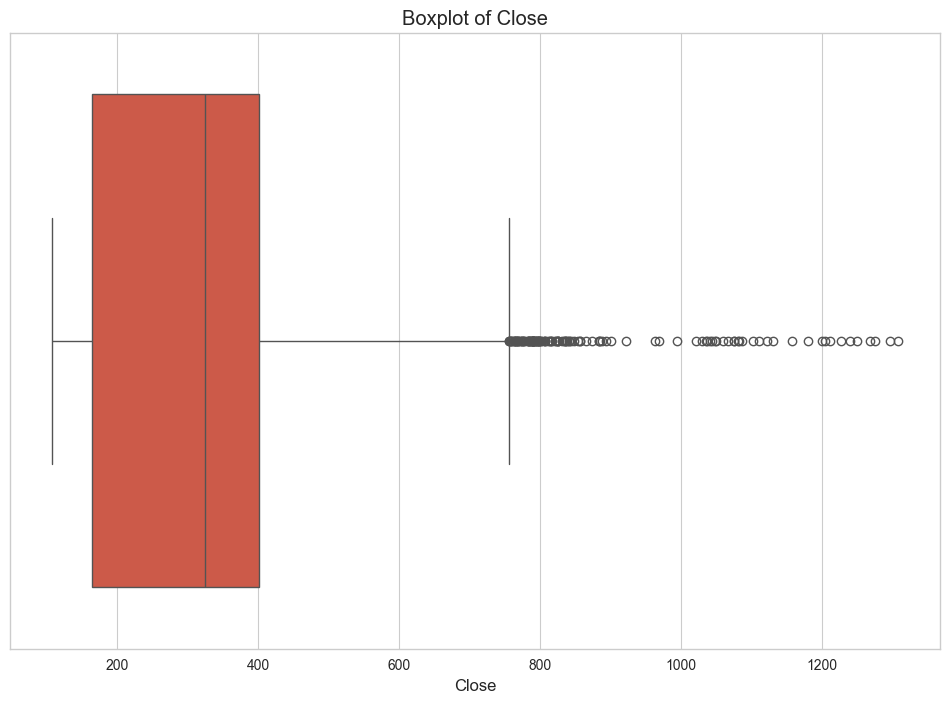

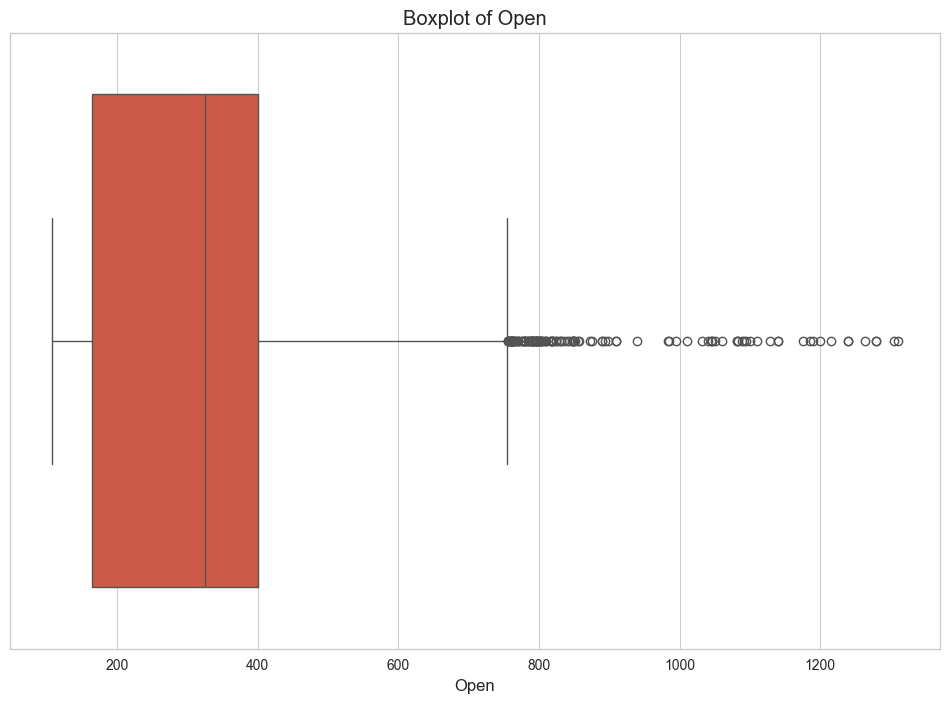

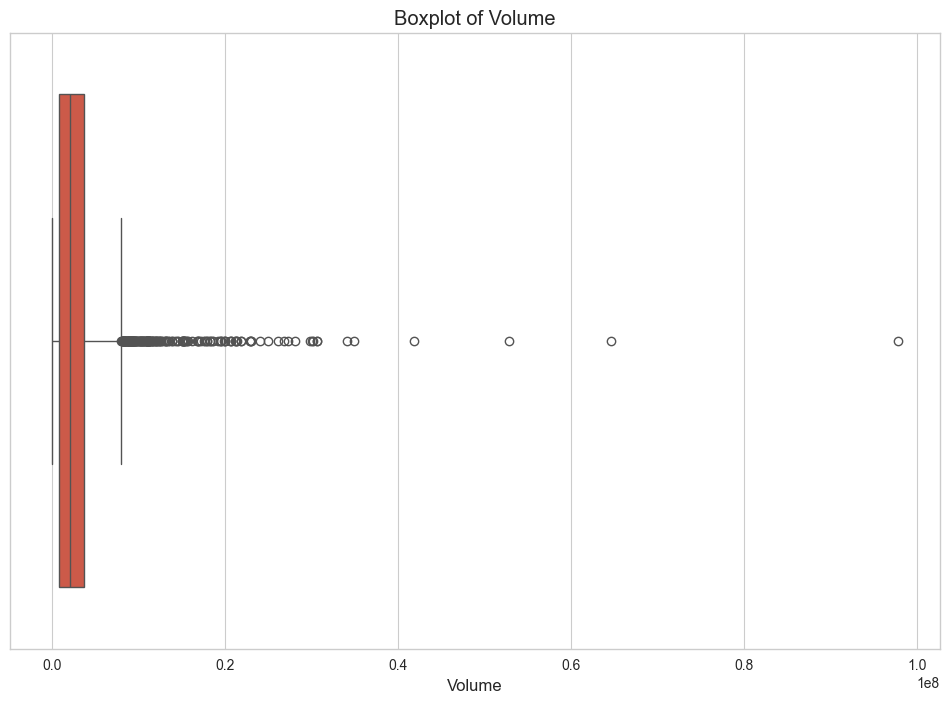

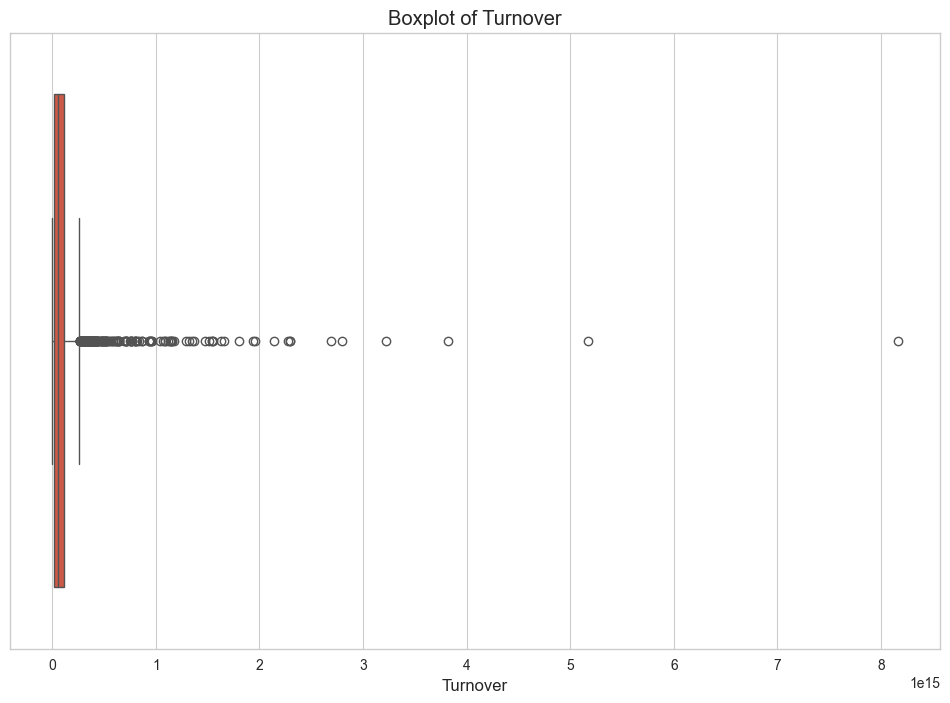

In [18]:
# Boxplots for outlier detection
print("\nOutlier Detection - Boxplots:")
for col in ['Close', 'Open', 'Volume', 'Turnover']:
    if col in df.columns:
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.show()

C:\Users\91932\AppData\Local\Temp\ipykernel_16016\4039637783.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


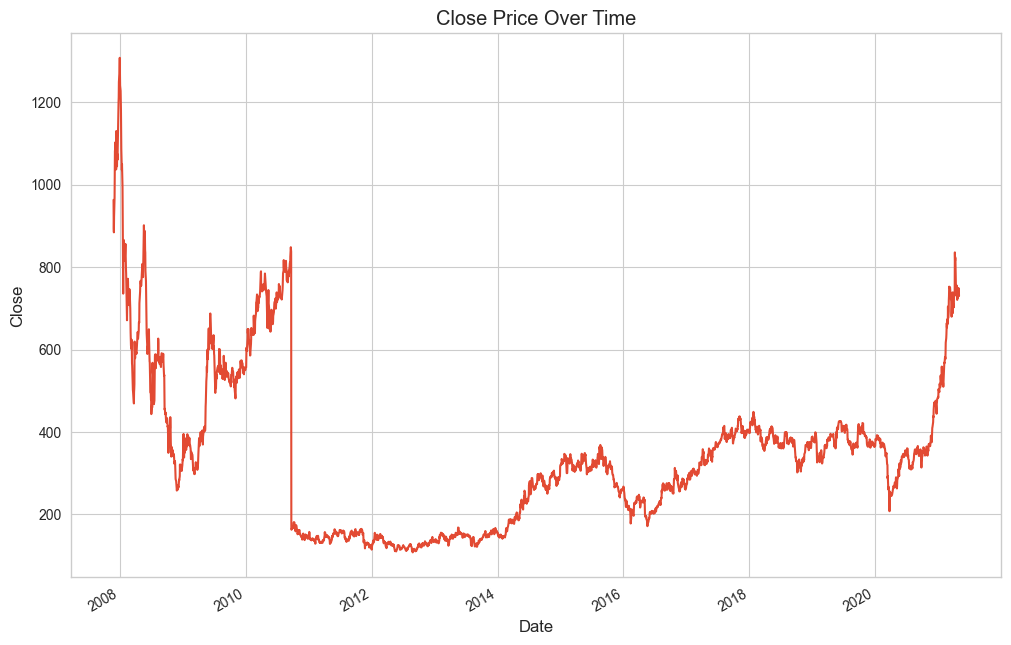

C:\Users\91932\AppData\Local\Temp\ipykernel_16016\4039637783.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['Close'].resample('M').mean()


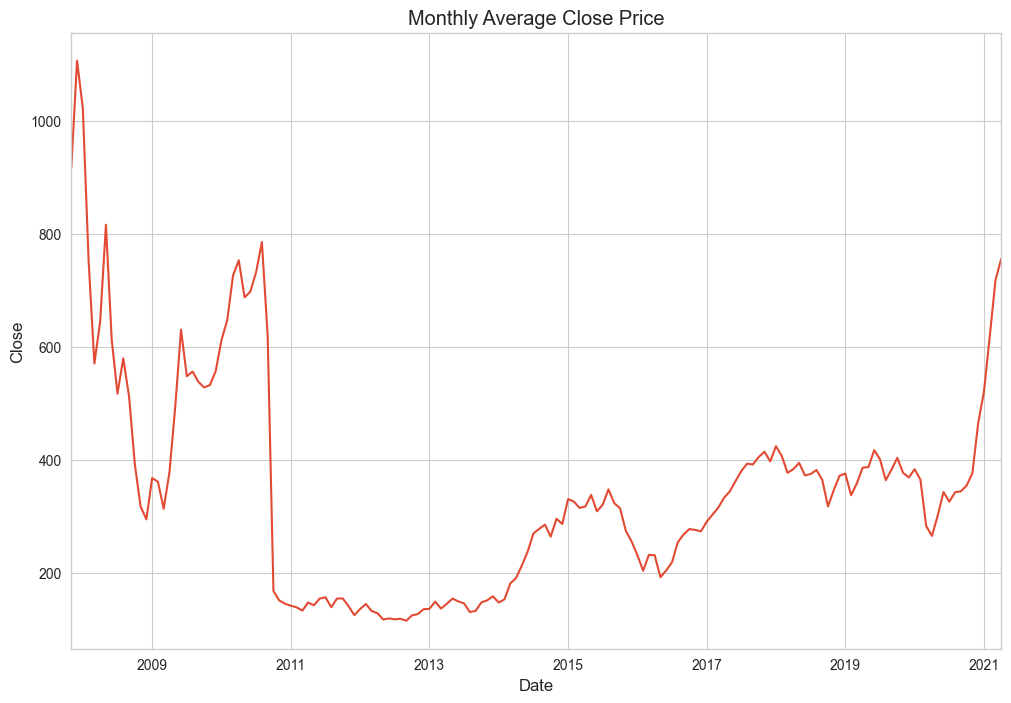

In [19]:
# Time series visualization
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if 'Close' in df.columns:
        df['Close'].plot()
        plt.title('Close Price Over Time')
        plt.ylabel('Close')
        plt.show()

    monthly_avg = df['Close'].resample('M').mean()
    monthly_avg.plot()
    plt.title('Monthly Average Close Price')
    plt.ylabel('Close')
    plt.show()

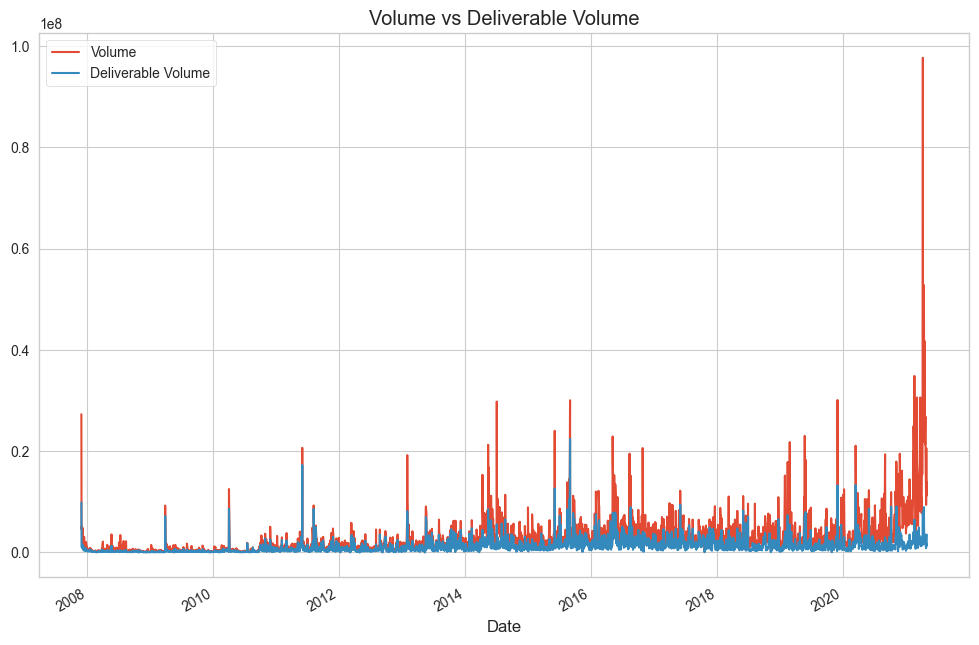

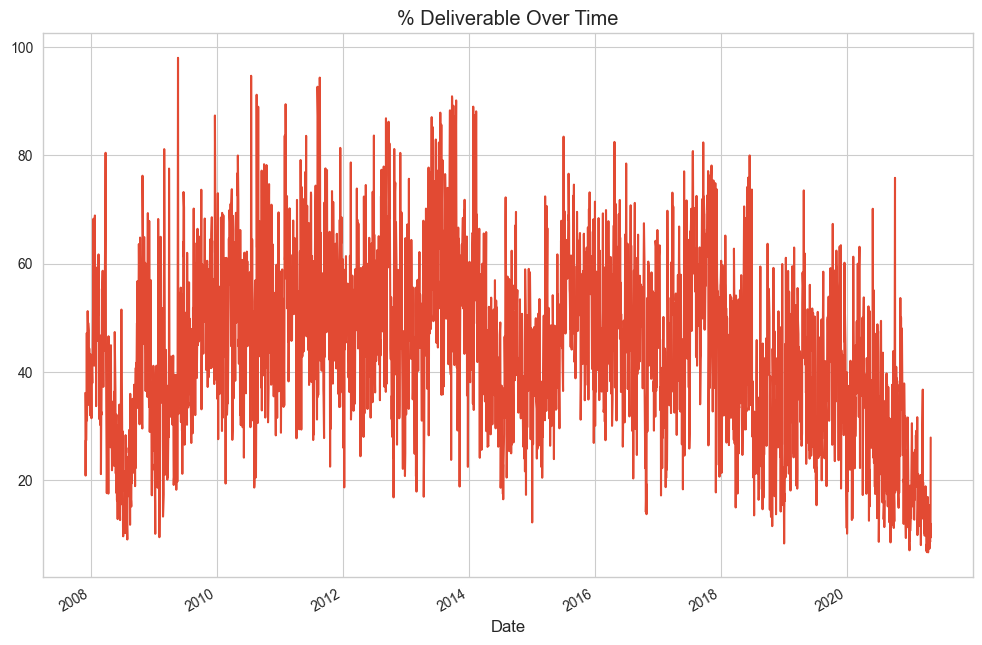

In [20]:
# Volume trends
if 'Volume' in df.columns and 'Deliverable Volume' in df.columns:
    df['%Deliverble'] = (df['Deliverable Volume'] / df['Volume']) * 100
    df[['Volume', 'Deliverable Volume']].plot()
    plt.title('Volume vs Deliverable Volume')
    plt.show()

    df['%Deliverble'].plot()
    plt.title('% Deliverable Over Time')
    plt.show()

In [21]:
# Final dataset shape and columns
print("\nFinal Shape:", df.shape)


Final Shape: (3322, 15)


In [22]:
print("Columns after preprocessing:\n", df.columns.tolist())

Columns after preprocessing:
 ['Symbol', 'Series', 'Prev Close', 'Open', 'Close', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'Daily Change', 'Change %', 'MA_5', 'MA_10', 'STD_5']


In [23]:
import pandas as pd
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop any missing values
df = df.dropna()

# Define features and target
features = df[['Open', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', 'MA_5', 'MA_10', 'STD_5']]
target = df['Close']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.8, random_state=42)

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "AdaBoost Regressor": AdaBoostRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = math.sqrt(mse)

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

# Show results
results_df = pd.DataFrame(results)
print("📊 Model Performance Comparison:")
print(results_df.sort_values(by="R2 Score", ascending=False))


📊 Model Performance Comparison:
                      Model  R2 Score         MAE           MSE        RMSE
6         Gradient Boosting  0.993910    7.739124    226.457323   15.048499
2             Random Forest  0.993002    7.862780    260.220955   16.131366
0         Linear Regression  0.991590    8.277784    312.710227   17.683615
1             Decision Tree  0.990333   10.096990    359.458849   18.959400
5        AdaBoost Regressor  0.986171   13.200040    514.192631   22.675816
3  Support Vector Regressor  0.003575  138.928063  37049.829794  192.483323
4             KNN Regressor -0.112062  143.961129  41349.532965  203.345846


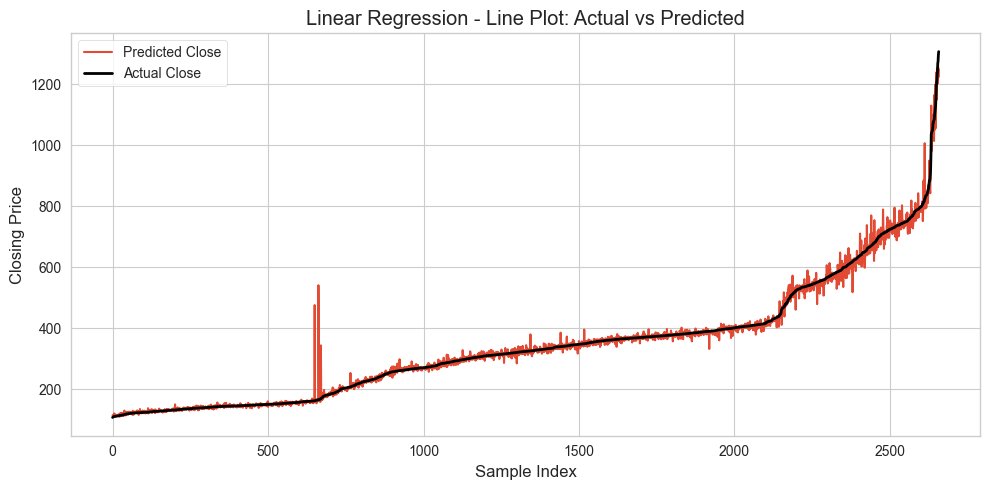

c:\Users\91932\anaconda3\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\91932\anaconda3\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


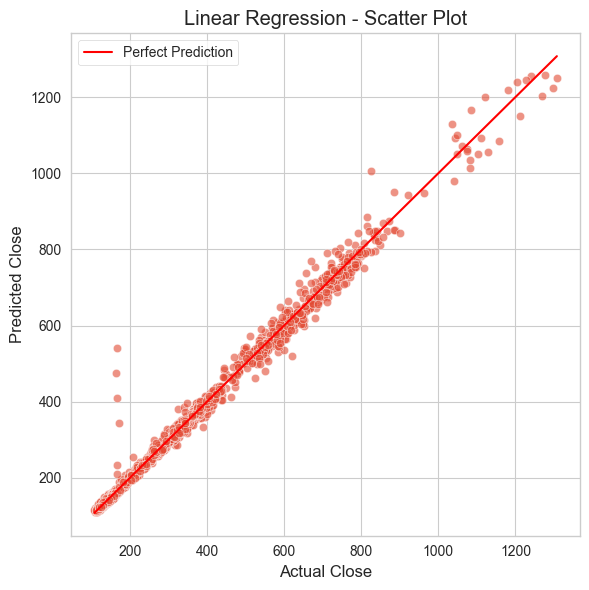

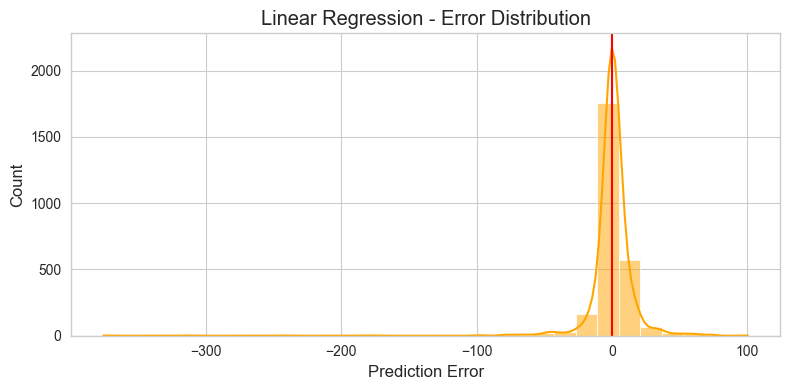

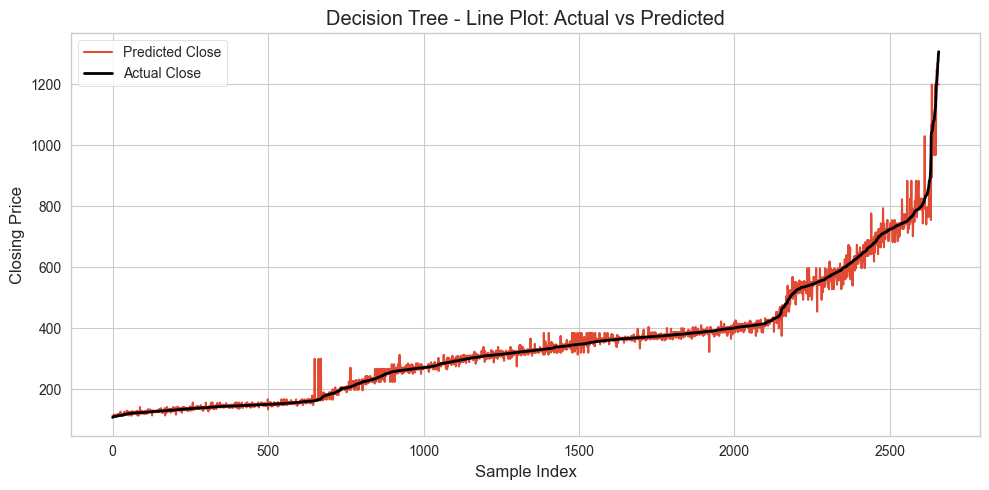

c:\Users\91932\anaconda3\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\91932\anaconda3\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


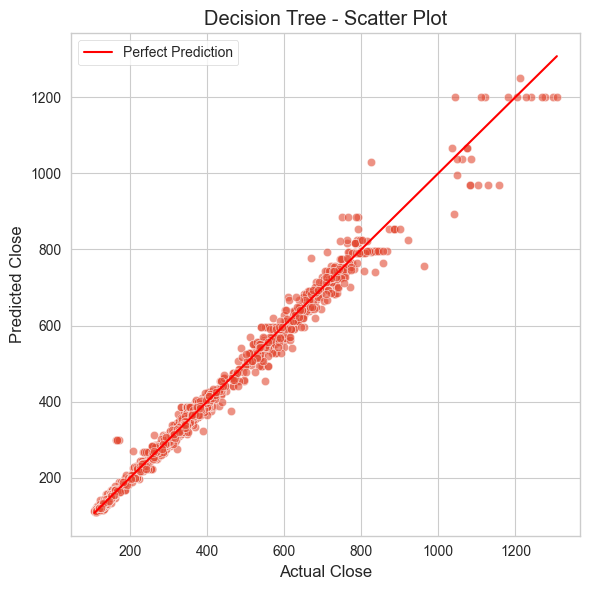

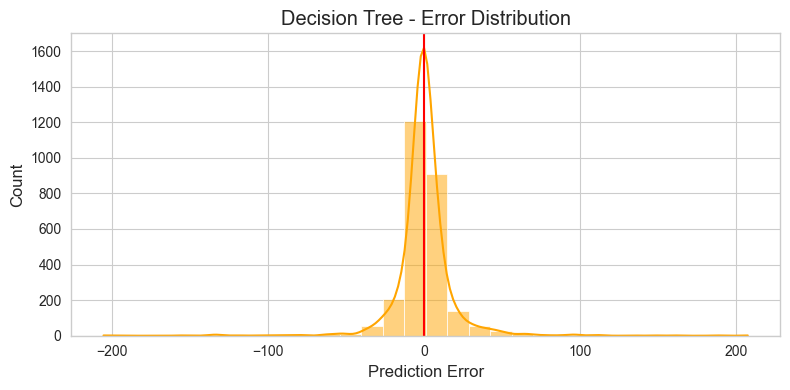

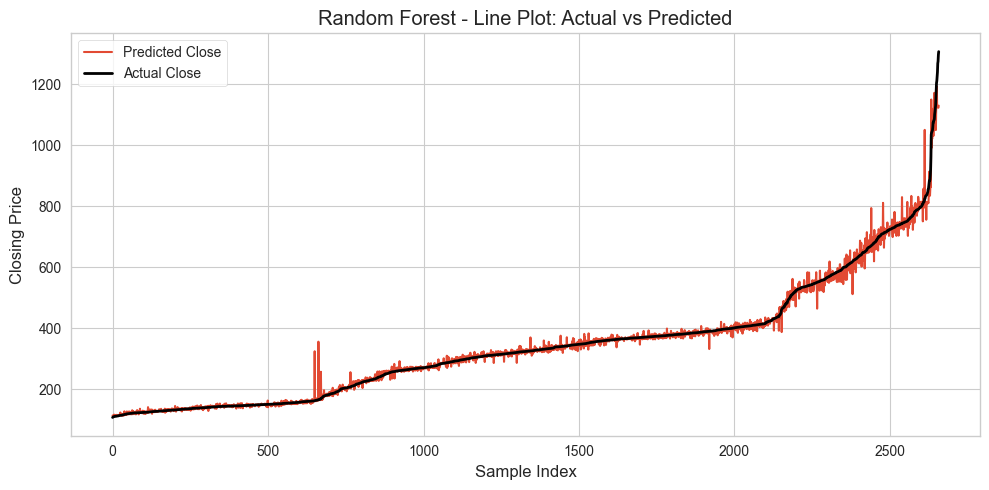

c:\Users\91932\anaconda3\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\91932\anaconda3\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


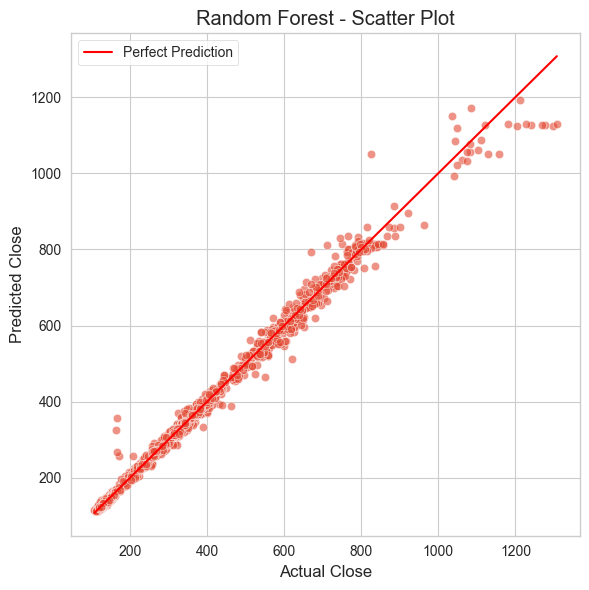

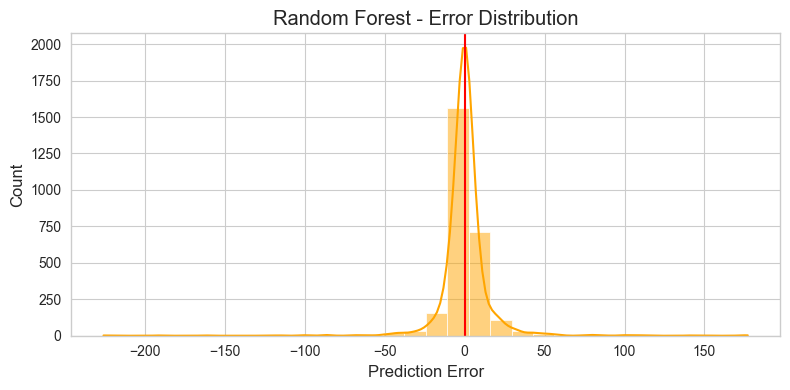

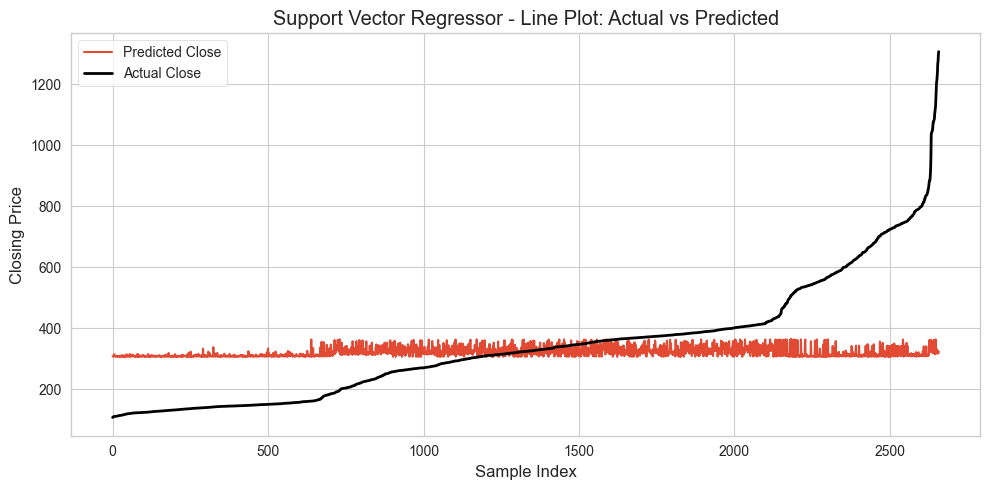

c:\Users\91932\anaconda3\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\91932\anaconda3\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


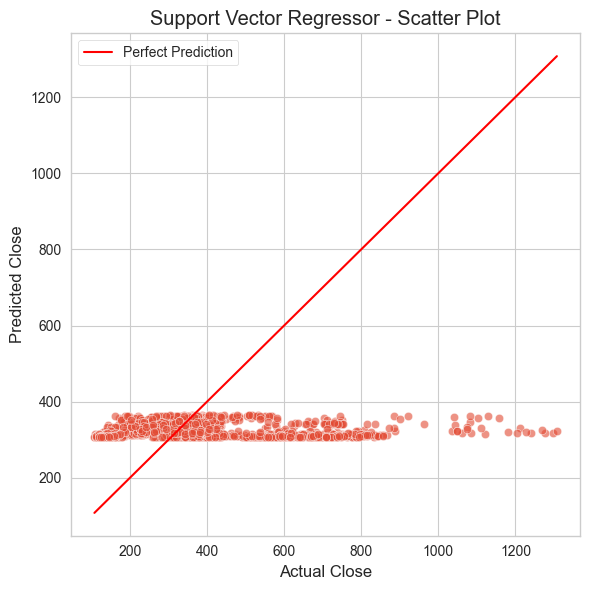

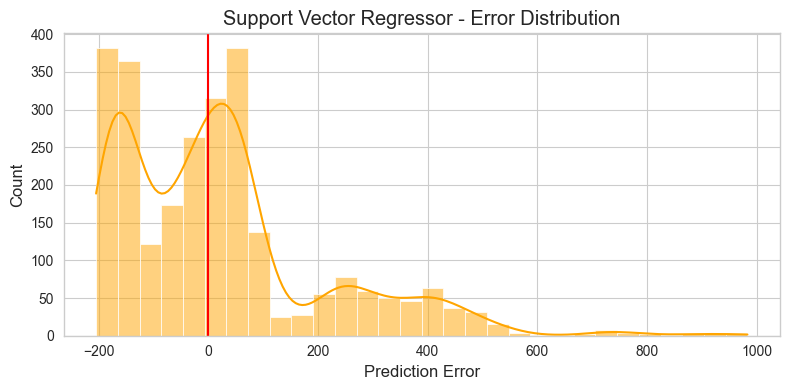

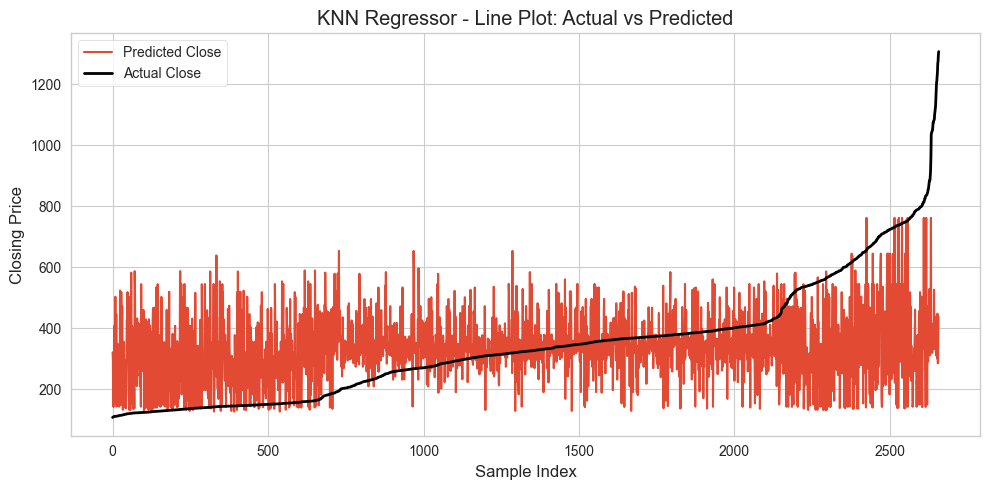

c:\Users\91932\anaconda3\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\91932\anaconda3\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


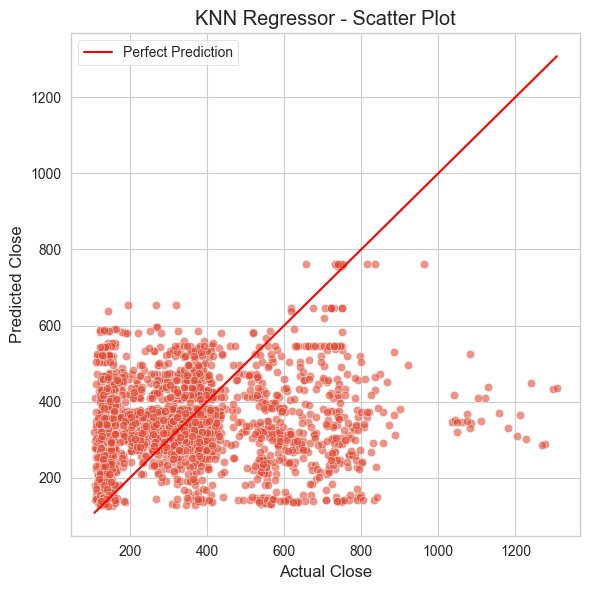

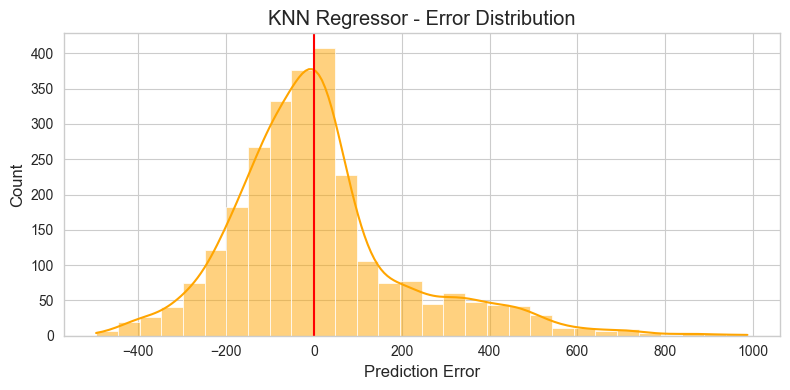

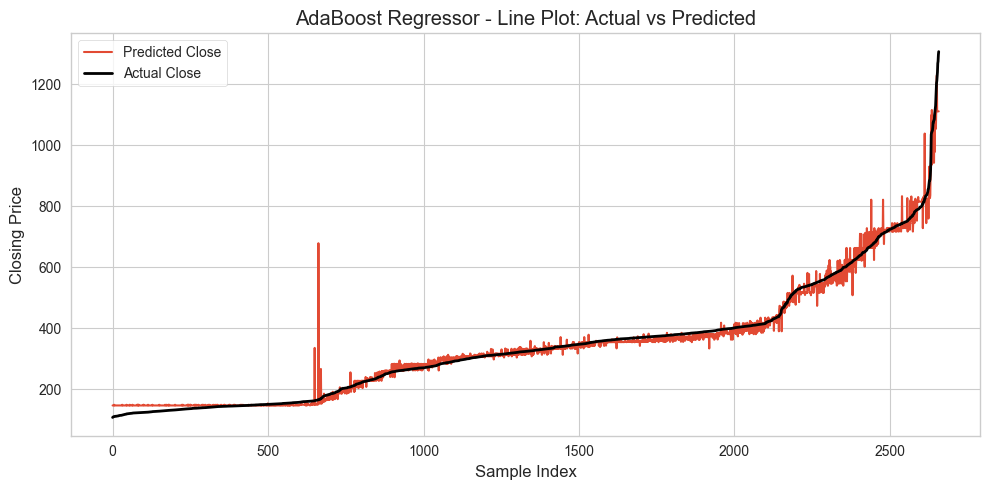

c:\Users\91932\anaconda3\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\91932\anaconda3\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


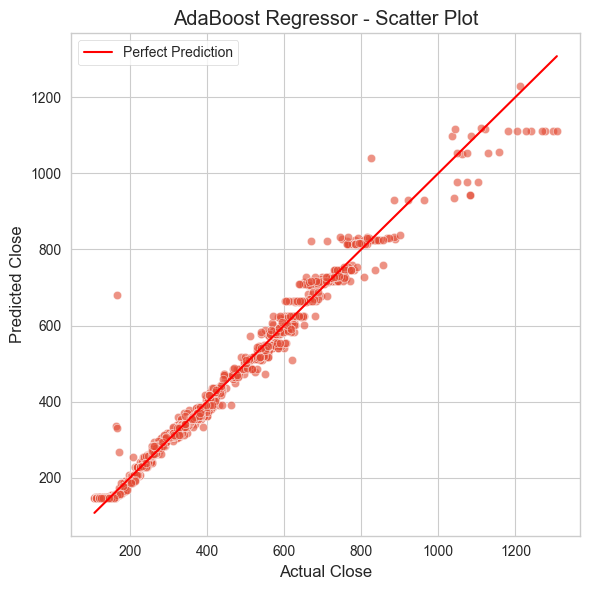

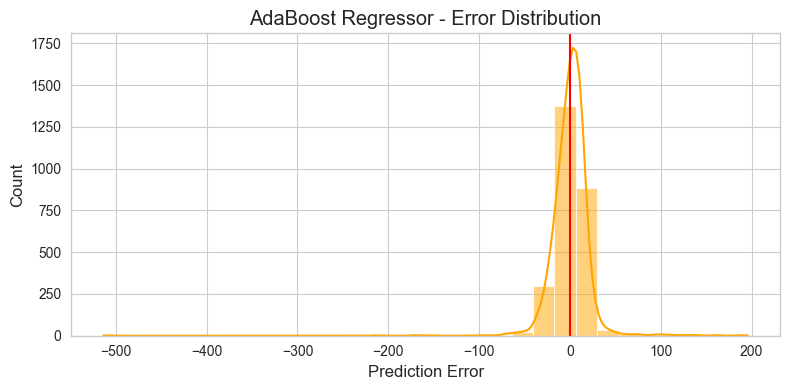

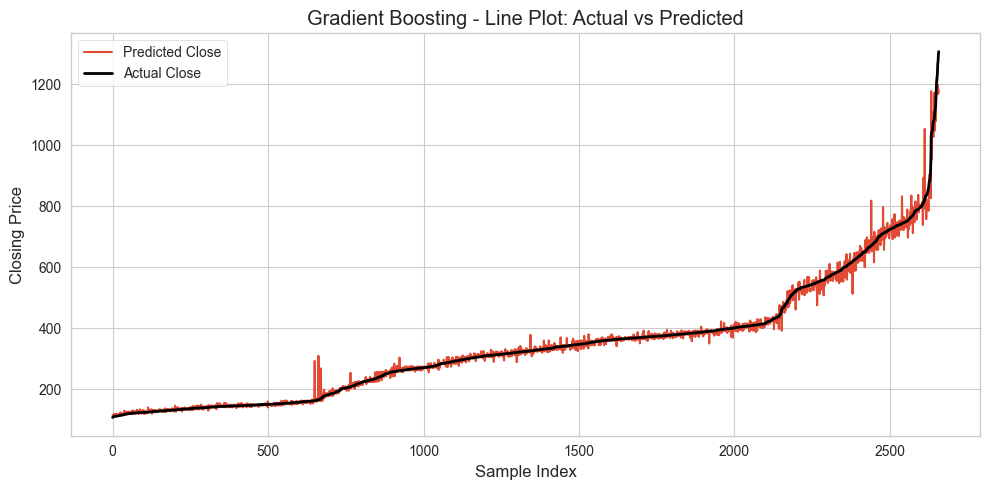

c:\Users\91932\anaconda3\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\91932\anaconda3\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


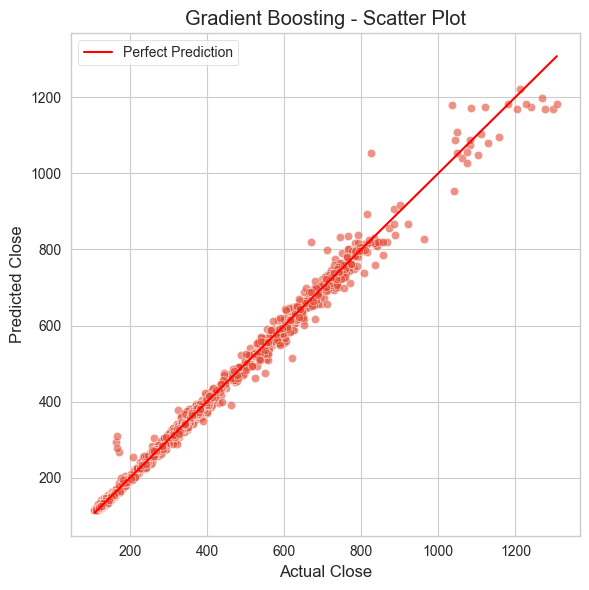

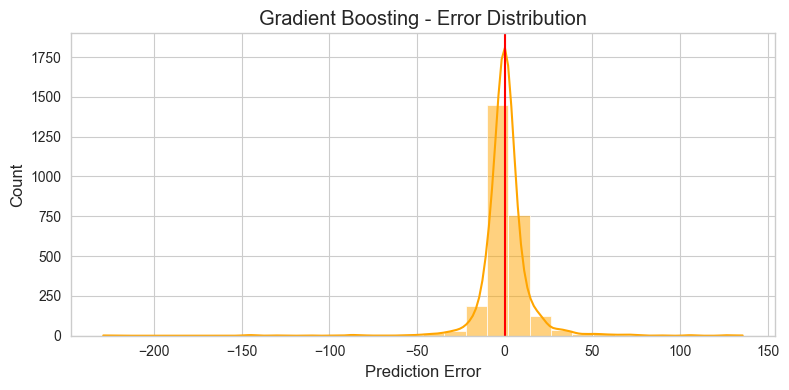

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create directory to save plots
os.makedirs("model_plots", exist_ok=True)

# Loop through models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Sort predictions for better line plotting
    sorted_idx = y_test.argsort()
    y_test_sorted = y_test.iloc[sorted_idx]
    y_pred_sorted = pd.Series(y_pred, index=y_test.index).iloc[sorted_idx]

    # --- LINE PLOT: Actual vs Predicted ---
    plt.figure(figsize=(10, 5))
    plt.plot(y_pred_sorted.values, label="Predicted Close", linestyle='-')
    plt.plot(y_test_sorted.values, label="Actual Close", color='black', linewidth=2)
    plt.title(f"{name} - Line Plot: Actual vs Predicted")
    plt.xlabel("Sample Index")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"model_plots/{name}_line_plot.png")
    plt.show()

    # --- SCATTER PLOT: Actual vs Predicted ---
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6,cmap="turbo")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '-r', label="Perfect Prediction")
    plt.xlabel("Actual Close")
    plt.ylabel("Predicted Close")
    plt.title(f"{name} - Scatter Plot")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"model_plots/{name}_scatter_plot.png")
    plt.show()

    # --- ERROR HISTOGRAM: y_true - y_pred ---
    errors = y_test - y_pred
    plt.figure(figsize=(8, 4))
    sns.histplot(errors, bins=30, kde=True, color='orange')
    plt.axvline(0, color='red', linestyle='-')
    plt.title(f"{name} - Error Distribution")
    plt.xlabel("Prediction Error")
    plt.tight_layout()
    plt.savefig(f"model_plots/{name}_error_histogram.png")
    plt.show()


## 1. Linear Regression Assumptions
### ✅ Assumptions:
###### Linearity: Relationship between features and target is linear.
###### Homoscedasticity: Constant variance of residuals.
###### Independence: Observations are independent.
###### Normality of residuals: Residuals are normally distributed.
###### No multicollinearity: Independent variables are not highly correlated.

### 💡 Interpretation:
###### Linearity & Homoscedasticity: Residuals should be randomly scattered (not funnel-shaped).
###### Normality: Histogram & Q-Q plot should look symmetric; slight deviations are okay.
###### VIF: Values > 10 indicate high multicollinearity.

In [25]:

# Fit linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
residuals = y_test - y_pred_lin

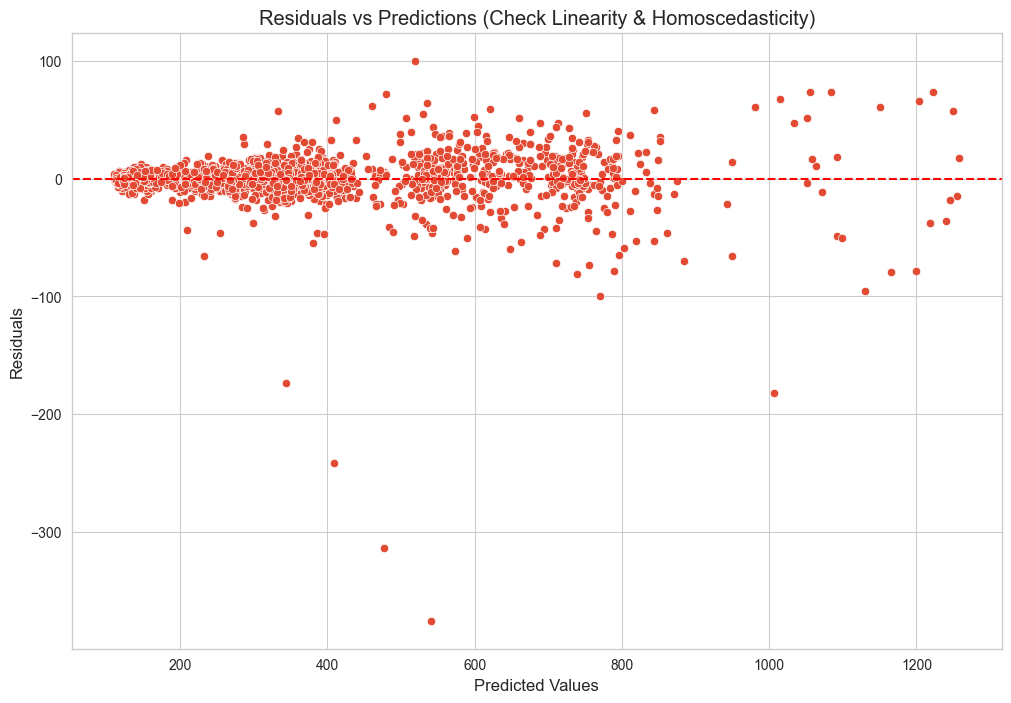

In [26]:
# A. Linearity & Homoscedasticity:

import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred_lin
sns.scatterplot(x=y_pred_lin, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions (Check Linearity & Homoscedasticity)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


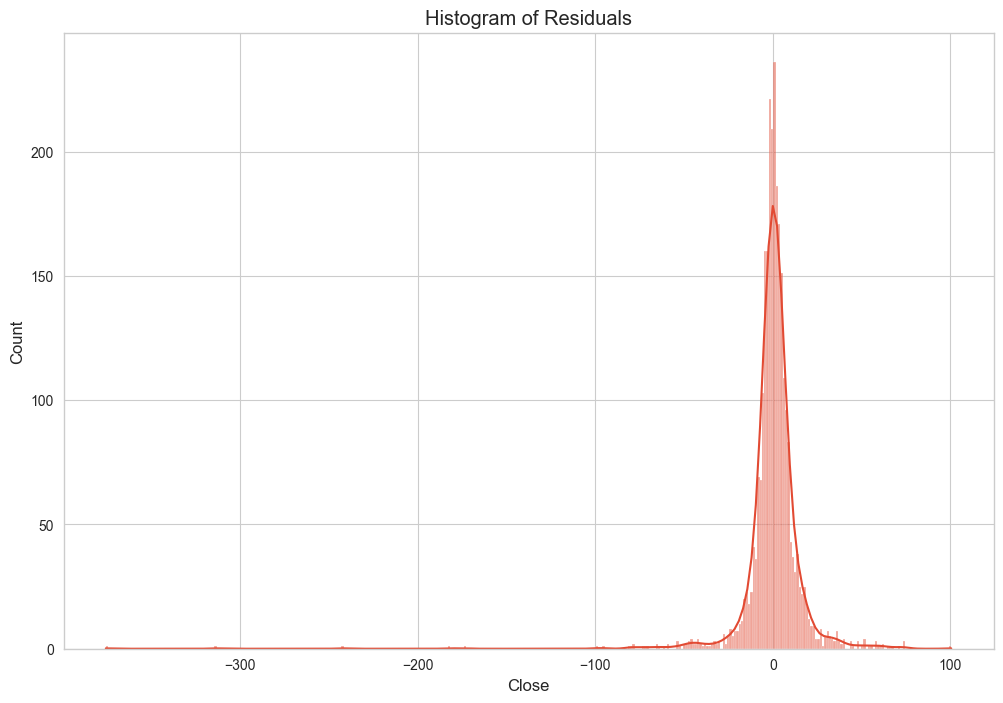

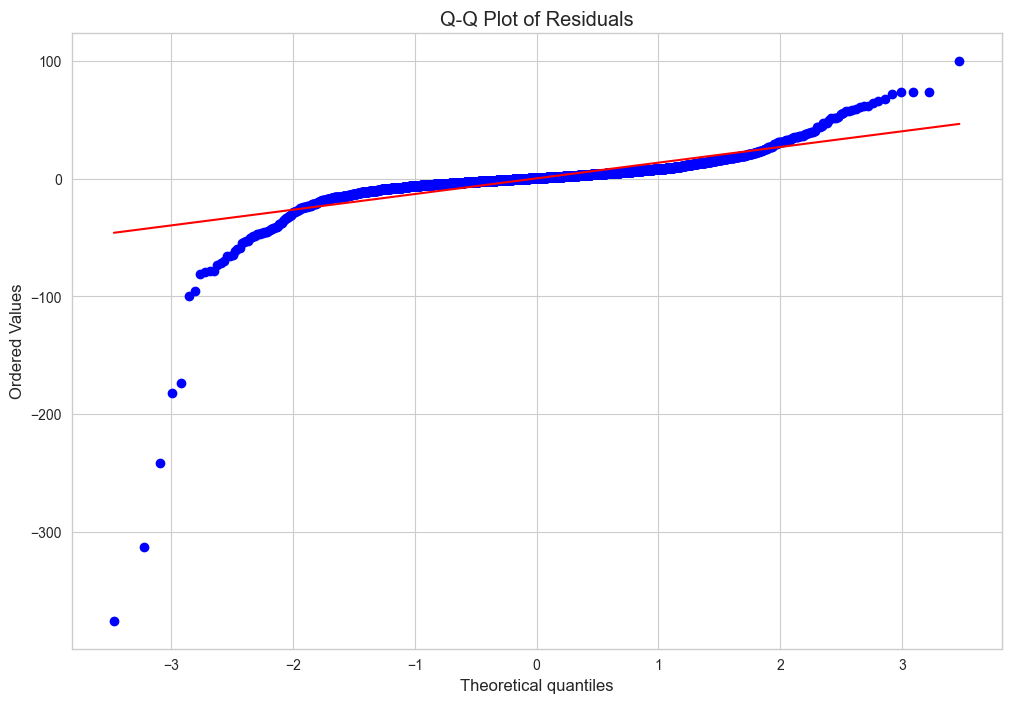

In [27]:
# B. Normality Check:

from scipy import stats
import numpy as np

# Histogram
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

# Q-Q plot without statsmodels
import scipy.stats as stats
import matplotlib.pyplot as plt
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


In [28]:
# C. VIF -Variance Influence Factor

from sklearn.linear_model import LinearRegression

def compute_vif(X):
    vif = []
    for i in range(X.shape[1]):
        X_i = X.drop(X.columns[i], axis=1)
        y_i = X.iloc[:, i]
        model = LinearRegression().fit(X_i, y_i)
        r_squared = model.score(X_i, y_i)
        vif_value = 1 / (1 - r_squared)
        vif.append(vif_value)
    return pd.DataFrame({'Feature': X.columns, 'VIF': vif})

vif_data = compute_vif(X_train)
print(vif_data)


              Feature         VIF
0                Open  107.354408
1              Volume   16.121611
2            Turnover   10.678210
3              Trades    8.895670
4  Deliverable Volume    3.392322
5                MA_5  316.540213
6               MA_10   71.205866
7               STD_5    1.671462


## 2. Decision Tree Assumptions
### ✅ Assumptions:
###### ✅ No assumptions about feature distribution
###### ✅ No need for linearity or normality
###### ✅ Handles multicollinearity and non-linear relationships well

### 💡 Interpretation:
###### Decision Trees are non-parametric, so they don’t require assumption testing.
###### But visualizing feature importance gives insight into model logic.

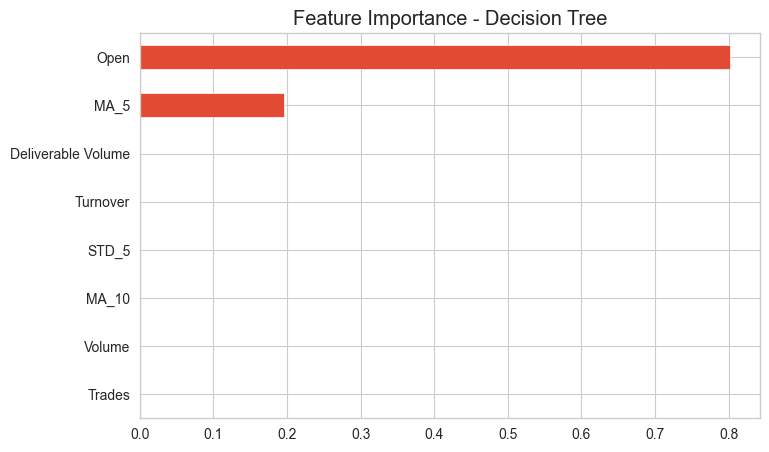

In [29]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance - Decision Tree")
plt.show()


## 3. Random Forest Assumptions
### ✅ Assumptions: Same as Decision Tree
###### ✅ No assumptions about feature distribution
###### ✅ No need for linearity or normality
###### ✅ Handles multicollinearity and non-linear relationships well

### 💡 Interpretation:
###### The residuals should be randomly spread.
###### Forest models tend to overfit if data is noisy or sparse.

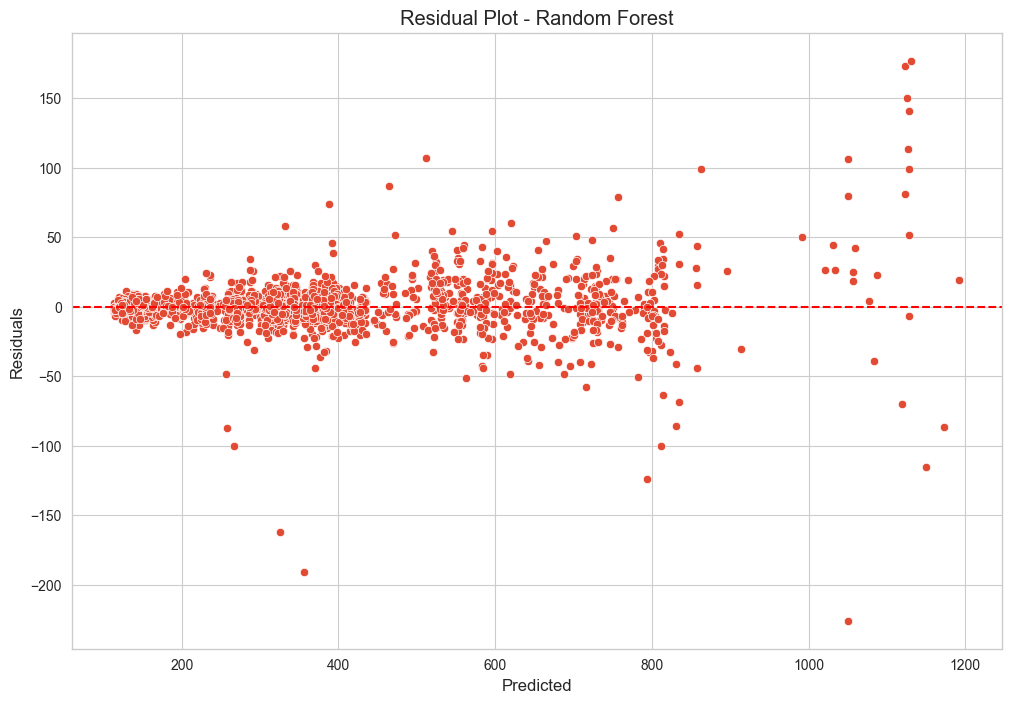

In [30]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
residuals_rf = y_test - y_pred_rf

# Residual Plot
sns.scatterplot(x=y_pred_rf, y=residuals_rf)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


## 4. Support Vector Regression (SVR) Assumptions
### ✅ Assumptions: No strict assumptions, but:
###### Works best when features are standardized
###### Sensitive to outliers and scaling
###### The choice of kernel impacts results

### 💡 Interpretation:
###### If residuals are randomly distributed, you're good.
###### Always standardize your features for SVR.

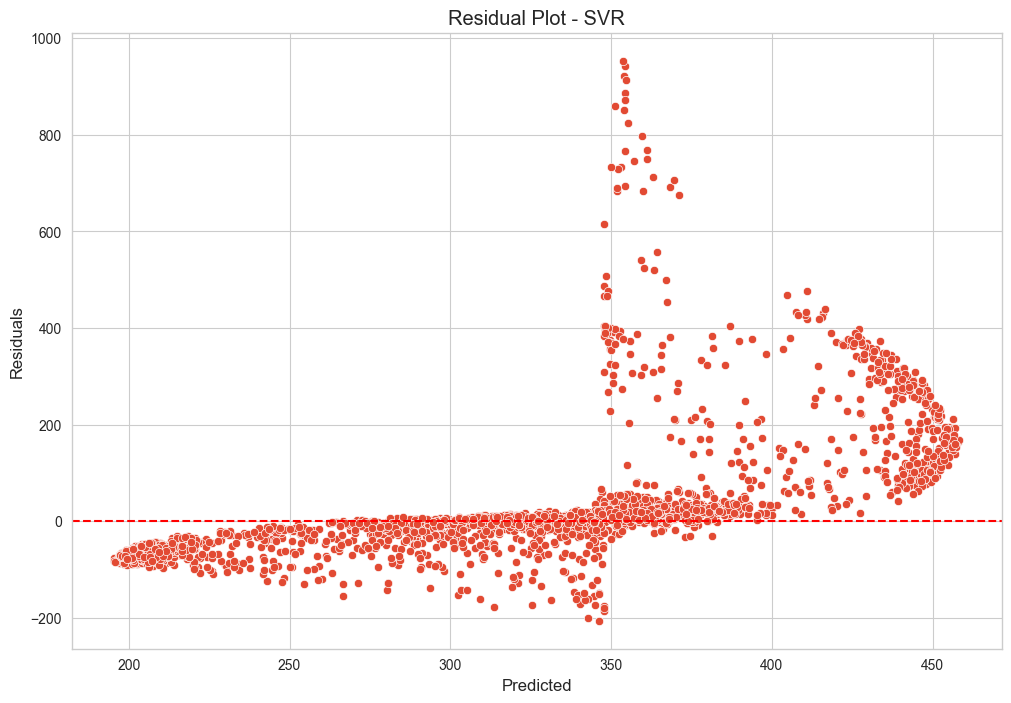

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)
residuals_svr = y_test - y_pred_svr

# Residual Plot
sns.scatterplot(x=y_pred_svr, y=residuals_svr)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot - SVR")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()
